In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_style("whitegrid")

In [37]:
import pandas as pd

df = pd.read_excel("MLDataset-CoffeePOS.xlsx")

df.head()

,Date,Day,Month,Time_Period,Total_Orders,Total_Items_Sold,Drinks_Sold,Desserts_Sold,Hot_Drinks,Cold_Drinks,Avg_Order_Value,Revenue,Ingredient_Cost,Profit,Weekend,Holiday,Promotion,Weather,Customer_Rating
0,2026-01-01,Thursday,January,Morning,95,142,110,32,90,20,8.4,798,340,458,No,Yes,Yes,Rainy,4.5
1,2026-01-02,Friday,January,Afternoon,120,175,135,40,100,35,8.9,1068,470,598,No,No,No,Cloudy,4.4
2,2026-01-03,Saturday,January,Evening,185,260,200,60,145,55,9.8,1813,790,1023,Yes,No,Yes,Cold,4.7
3,2026-01-04,Sunday,January,Morning,170,248,190,58,150,40,9.3,1581,680,901,Yes,No,No,Sunny,4.6
4,2026-01-05,Monday,January,Afternoon,88,128,100,28,80,20,7.8,686,300,386,No,No,No,Rainy,4.2


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Total_Orders         365 non-null    int64  
 1   Total_Items_Sold     365 non-null    int64  
 2   Drinks_Sold          365 non-null    int64  
 3   Desserts_Sold        365 non-null    int64  
 4   Hot_Drinks           365 non-null    int64  
 5   Cold_Drinks          365 non-null    int64  
 6   Avg_Order_Value      365 non-null    float64
 7   Revenue              365 non-null    int64  
 8   Ingredient_Cost      365 non-null    int64  
 9   Profit               365 non-null    int64  
 10  Weekend              365 non-null    int64  
 11  Holiday              365 non-null    int64  
 12  Promotion            365 non-null    int64  
 13  Customer_Rating      365 non-null    float64
 14  Day_Monday           365 non-null    bool   
 15  Day_Saturday         365 non-null    boo

In [38]:
df = df.drop(columns=['Date'])

df = df.replace({'Yes': 1, 'No': 0})

df = pd.get_dummies(df, drop_first=True)

/tmp/ipykernel_16632/2005834806.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Yes': 1, 'No': 0})


In [39]:
# Classification target
df['Profit_Class'] = (df['Profit'] > df['Profit'].mean()).astype(int)

In [40]:
X_reg = df.drop(columns=['Profit', 'Profit_Class'])
y_reg = df['Profit']

In [41]:
X_clf = df.drop(columns=['Profit', 'Profit_Class'])
y_clf = df['Profit_Class']

Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Classification split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Regression
X_train_reg = scaler.fit_transform(X_train_reg)
X_test_reg = scaler.transform(X_test_reg)

# Classification
X_train_clf = scaler.fit_transform(X_train_clf)
X_test_clf = scaler.transform(X_test_clf)

Linear Regression

R2: 1.0
MSE: 2.1593096641046073e-24


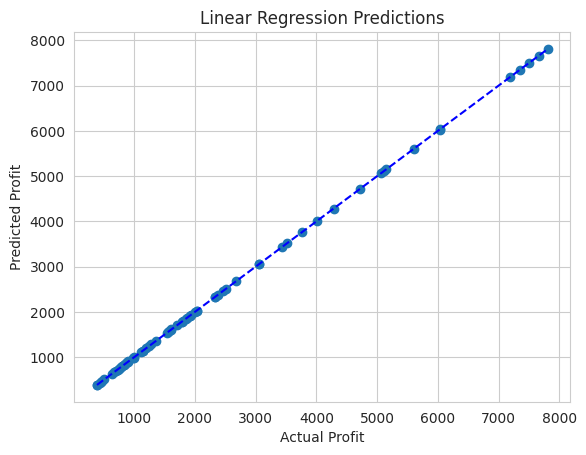

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

lr = LinearRegression()
lr.fit(X_train_reg, y_train_reg)

y_pred_lr = lr.predict(X_test_reg)

print("R2:", r2_score(y_test_reg, y_pred_lr))
print("MSE:", mean_squared_error(y_test_reg, y_pred_lr))

plt.scatter(y_test_reg, y_pred_lr)

plt.plot([min(y_test_reg), max(y_test_reg)],
         [min(y_test_reg), max(y_test_reg)],
         color='blue', linestyle='--')

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Linear Regression Predictions")

plt.show()

Classifaction Models

Logisitic Registration

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

log_model = LogisticRegression(max_iter=3000)
log_model.fit(X_train_clf, y_train_clf)

y_pred_log = log_model.predict(X_test_clf)

print("Logistic Accuracy:", accuracy_score(y_test_clf, y_pred_log))

Logistic Accuracy: 0.9863013698630136


Decsion Tree

In [47]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_clf, y_train_clf)

y_pred_dt = dt_model.predict(X_test_clf)

print("Decision Tree Accuracy:", accuracy_score(y_test_clf, y_pred_dt))

Decision Tree Accuracy: 1.0


Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_clf, y_train_clf)

y_pred_rf = rf_model.predict(X_test_clf)

print("Random Forest Accuracy:", accuracy_score(y_test_clf, y_pred_rf))

Random Forest Accuracy: 1.0


Comparison Graph

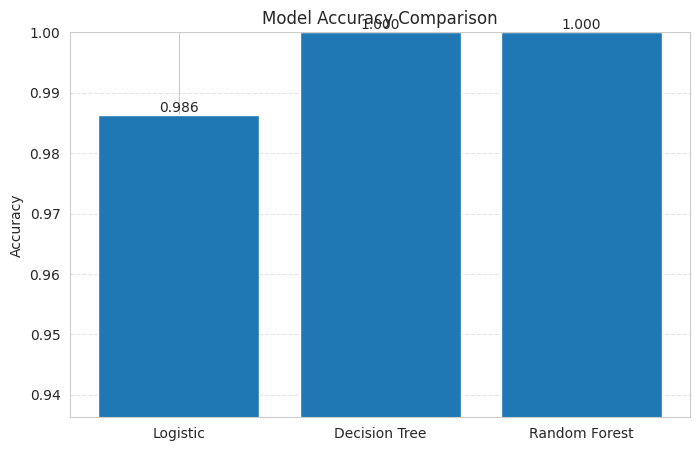

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

models = ["Logistic", "Decision Tree", "Random Forest"]
accuracies = [
    accuracy_score(y_test_clf, y_pred_log),
    accuracy_score(y_test_clf, y_pred_dt),
    accuracy_score(y_test_clf, y_pred_rf)
]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracies)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.3f}", ha='center', va='bottom')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

min_acc = min(accuracies)
plt.ylim(min_acc - 0.05, 1.0)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Confusion Matrix

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        linewidths=1,
        linecolor='black'
    )

    plt.title(title)
    plt.xlabel("Predicted (0=Low, 1=High)")
    plt.ylabel("Actual (0=Low, 1=High)")
    plt.show()

Logistic Regression CM

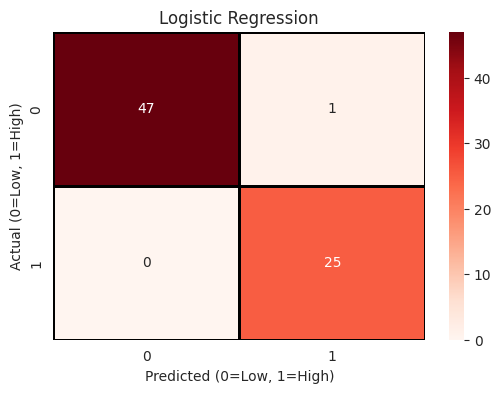

In [71]:
plot_cm(y_test_clf, y_pred_log, "Logistic Regression")


Decison Tree CM

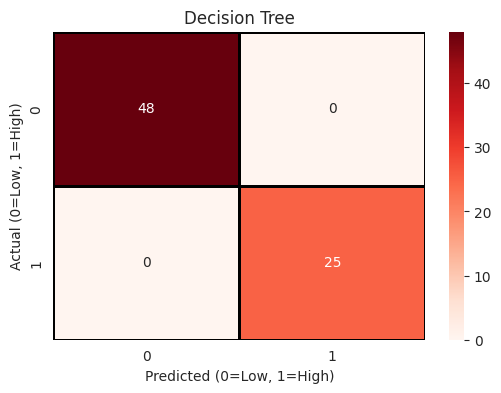

In [69]:

plot_cm(y_test_clf, y_pred_dt, "Decision Tree")


Random Forest CM

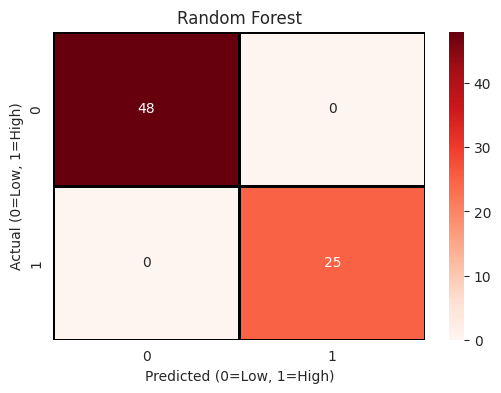

In [53]:
plot_cm(y_test_clf, y_pred_rf, "Random Forest")

Cross Validation

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modu

Logistic Regression CV Accuracy: 0.027367565370545993
Decision Tree CV Accuracy: 0.1067831820439868
Random Forest CV Accuracy: 0.15616673440816511


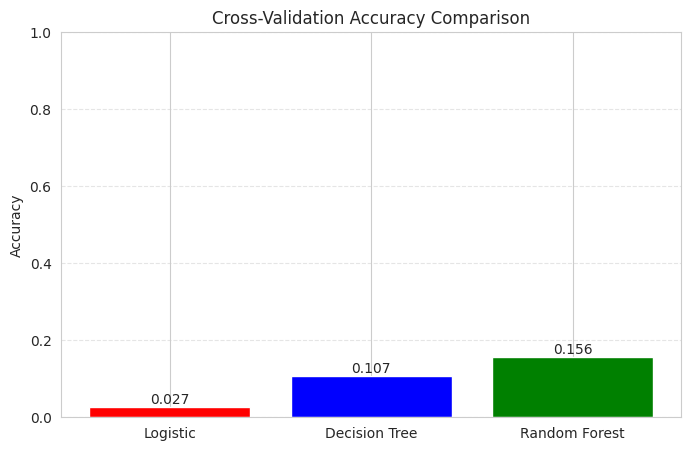

In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X = X.select_dtypes(include=['int64', 'float64'])
y = y

log_model = LogisticRegression(max_iter=3000)
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

from sklearn.model_selection import cross_val_score

log_scores = cross_val_score(log_model, X, y, cv=3, scoring='accuracy')
dt_scores = cross_val_score(dt_model, X, y, cv=3, scoring='accuracy')
rf_scores = cross_val_score(rf_model, X, y, cv=3, scoring='accuracy')

print("Logistic Regression CV Accuracy:", log_scores.mean())
print("Decision Tree CV Accuracy:", dt_scores.mean())
print("Random Forest CV Accuracy:", rf_scores.mean())

import matplotlib.pyplot as plt

models = ["Logistic", "Decision Tree", "Random Forest"]
scores = [log_scores.mean(), dt_scores.mean(), rf_scores.mean()]

plt.figure(figsize=(8,5))
bars = plt.bar(models, scores, color=['red', 'blue', 'green'])

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f"{yval:.3f}", ha='center', va='bottom')

plt.title("Cross-Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()